In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use("seaborn-v0_8")


Load Indian Stock Data

In [2]:
ticker = "RELIANCE.NS"

df = yf.download(
    ticker,
    start="2015-01-01",
    end="2025-01-01"
)

df = df[['Close']]
df.dropna(inplace=True)

df.head()



C:\Users\KRISHNENDU\AppData\Local\Temp\ipykernel_13788\2095722752.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,RELIANCE.NS
Date,
2015-01-01,189.999817
2015-01-02,189.496948
2015-01-05,187.421280
2015-01-06,178.915237
2015-01-07,182.809814


Plot the Raw Time Series

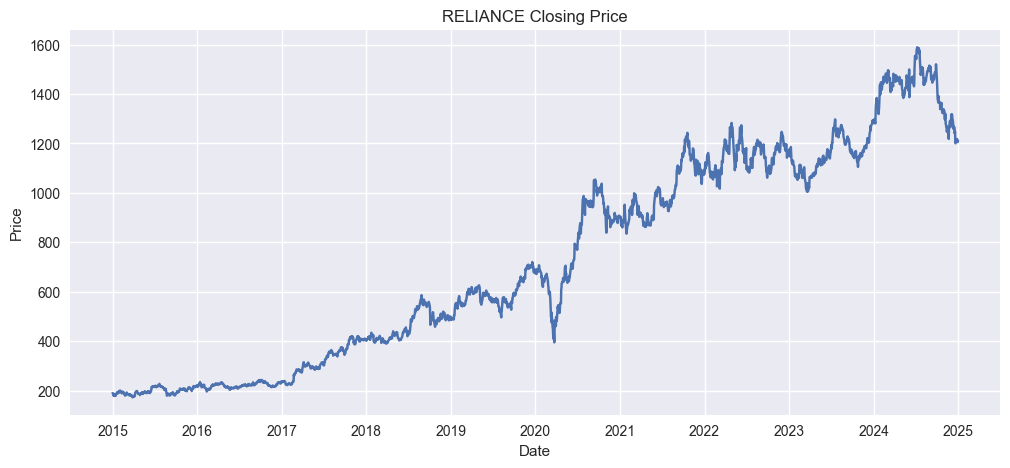

In [3]:
plt.figure(figsize=(12,5))
plt.plot(df['Close'])
plt.title("RELIANCE Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()



What is Stationarity? 

A time series is stationary if:
Mean is constant. Variance is constant. No trend. Stock prices are almost always non-stationary.

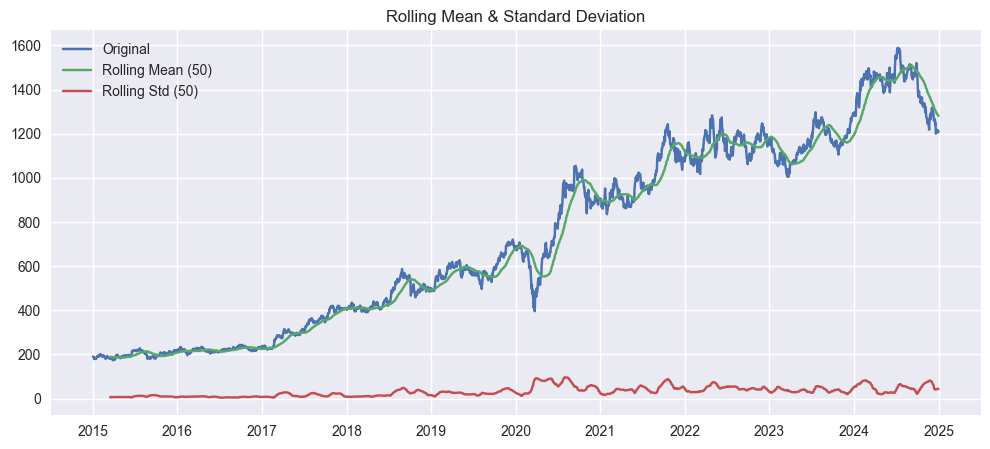

In [4]:
rolling_mean = df['Close'].rolling(window=50).mean()
rolling_std = df['Close'].rolling(window=50).std()

plt.figure(figsize=(12,5))
plt.plot(df['Close'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean (50)')
plt.plot(rolling_std, label='Rolling Std (50)')
plt.legend()
plt.title("Rolling Mean & Standard Deviation")
plt.show()


ADF Test (Statistical Test)

In [5]:
result = adfuller(df['Close'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])


ADF Statistic: -0.899361625471366
p-value: 0.788182570871816


First Order Differencing

In [6]:
df['Close_diff'] = df['Close'] - df['Close'].shift(1)
df.dropna(inplace=True)

df.head()


Price,Close,Close_diff
Ticker,RELIANCE.NS,
Date,,
2015-01-02,189.496948,-0.502869
2015-01-05,187.421280,-2.075668
2015-01-06,178.915237,-8.506042
2015-01-07,182.809814,3.894577
2015-01-08,180.188477,-2.621338


Plot Differenced Series

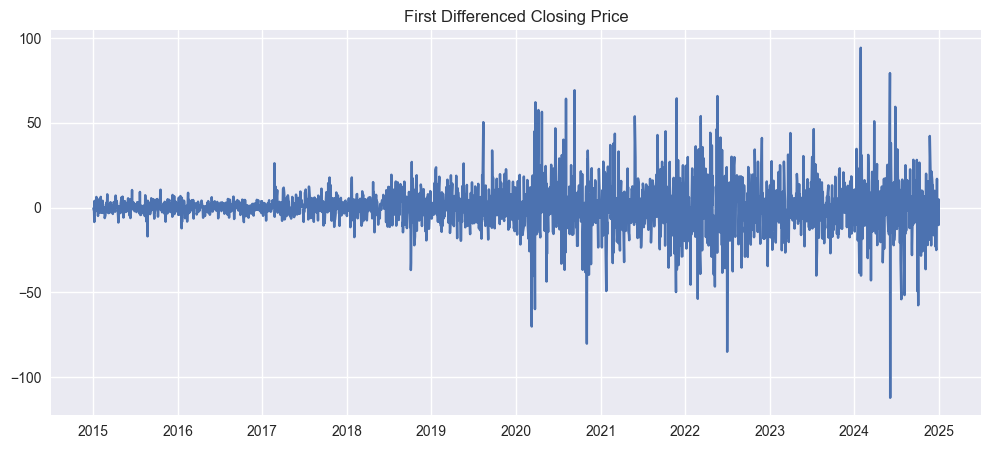

In [7]:
plt.figure(figsize=(12,5))
plt.plot(df['Close_diff'])
plt.title("First Differenced Closing Price")
plt.show()


ADF Test on Differenced Series

In [8]:
result_diff = adfuller(df['Close_diff'])

print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])


ADF Statistic: -29.848015481269016
p-value: 0.0


ACF Plot

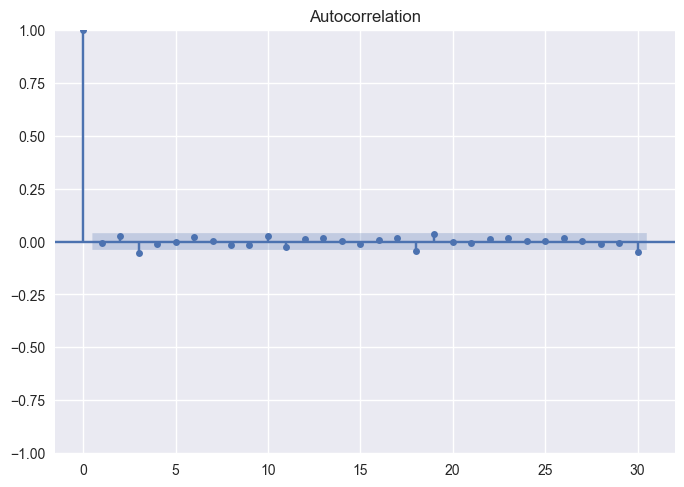

In [9]:
plot_acf(df['Close_diff'], lags=30)
plt.show()


PACF Plot

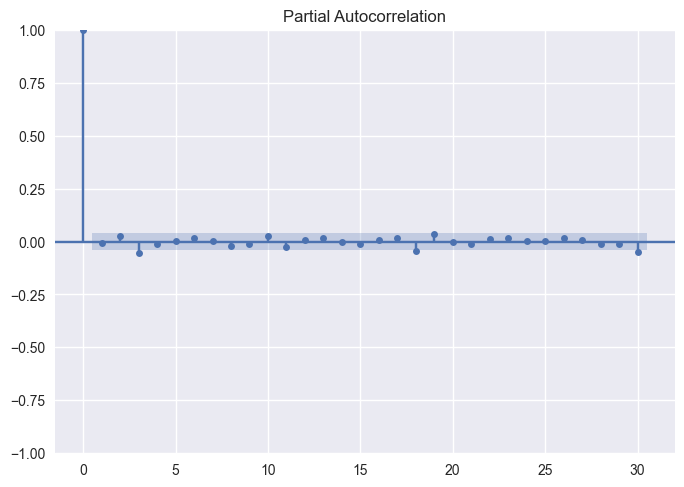

In [10]:
plot_pacf(df['Close_diff'], lags=30)
plt.show()
